In [ ]:
!pip install xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.4 MB/s eta 0:00:00


In [ ]:
import zipfile
import os

zip_file = "Temprature.zip"   # Change if your filename is different
extract_folder = "temperature"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Files extracted:")
print(os.listdir(extract_folder))

Files extracted:
['TMP-2m_2020050209_ncum_imdaa_reanl_2df_09.nc', 'TMP-2m_2020050122_ncum_imdaa_reanl_2df_22.nc', 'TMP-2m_2020050222_ncum_imdaa_reanl_2df_22.nc', 'TMP-2m_2020050109_ncum_imdaa_reanl_2df_09.nc', 'TMP-2m_2020050113_ncum_imdaa_reanl_2df_13.nc', 'TMP-2m_2020050213_ncum_imdaa_reanl_2df_13.nc']


In [ ]:
import xarray as xr

In [ ]:
ds = xr.open_dataset("temperature/TMP-2m_2020050113_ncum_imdaa_reanl_2df_13.nc")

In [ ]:
ds

<xarray.Dataset> Size: 760B
Dimensions:  (time: 1, height: 1, lat: 8, lon: 17)
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-05-01T13:00:00
  * height   (height) float64 8B 2.0
  * lat      (lat) float64 64B 28.08 28.2 28.32 28.44 28.56 28.68 28.8 28.92
  * lon      (lon) float64 136B 76.08 76.2 76.32 76.44 ... 77.76 77.88 78.0
Data variables:
    2t       (time, height, lat, lon) float32 544B ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Mon Jul 06 11:06:59 2026: cdo -f nc4c -z zip_4 sellonlatbox...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [ ]:
ds["2t"]

<xarray.DataArray '2t' (time: 1, height: 1, lat: 8, lon: 17)> Size: 544B
[136 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-05-01T13:00:00
  * height   (height) float64 8B 2.0
  * lat      (lat) float64 64B 28.08 28.2 28.32 28.44 28.56 28.68 28.8 28.92
  * lon      (lon) float64 136B 76.08 76.2 76.32 76.44 ... 77.76 77.88 78.0
Attributes:
    standard_name:  air_temperature
    long_name:      2 metre temperature
    units:          K
    param:          0.0.0

In [ ]:
ds["2t"].values

array([[[[310.10724, 310.10724, 310.076  , 309.6541 , 309.2635 ,
          309.0916 , 309.0291 , 308.98224, 308.99786, 308.79474,
          308.326  , 308.99786, 309.12286, 308.93536, 308.49786,
          307.93536, 307.49786],
         [310.1541 , 309.951  , 309.8885 , 309.74786, 309.04474,
          308.3885 , 308.2791 , 308.43536, 308.35724, 308.16974,
          308.701  , 308.8885 , 308.66974, 308.3885 , 307.826  ,
          307.3416 , 306.93536],
         [310.68536, 310.31036, 310.06036, 309.79474, 309.326  ,
          309.06036, 308.7791 , 308.201  , 308.3885 , 308.5135 ,
          308.5916 , 308.5291 , 308.201  , 307.79474, 307.18536,
          306.74786, 306.4041 ],
         [310.62286, 310.5135 , 310.3416 , 310.076  , 309.6541 ,
          309.451  , 309.1385 , 308.4666 , 308.7791 , 308.49786,
          308.68536, 308.29474, 307.7166 , 307.2635 , 306.576  ,
          306.16974, 305.8416 ],
         [310.5291 , 310.3885 , 310.49786, 310.3416 , 310.0135 ,
          309.74786, 30

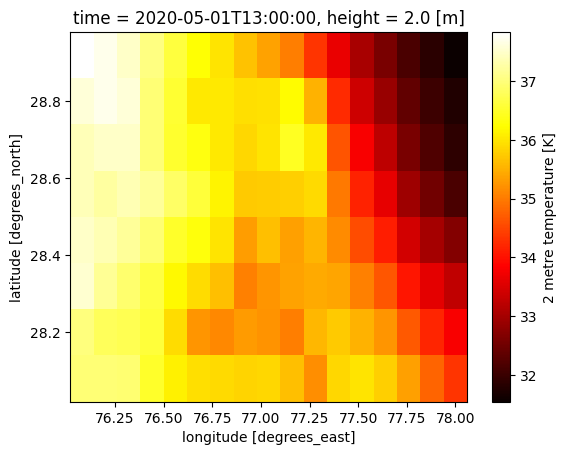

In [ ]:
temperature = ds["2t"] - 273.15

temperature.squeeze().plot(cmap="hot")

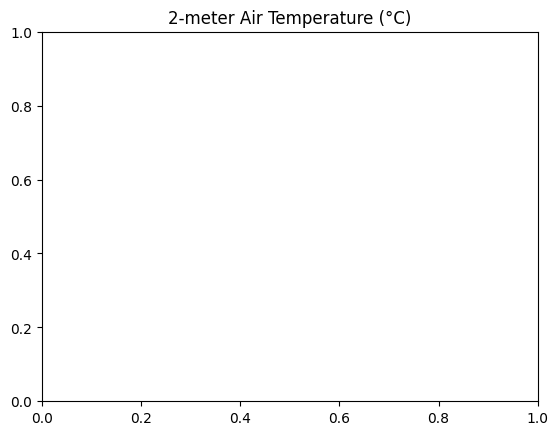

In [ ]:
import matplotlib.pyplot as plt

plt.title("2-meter Air Temperature (°C)")
plt.show()

In [ ]:
print(ds.lat.values)

[28.08 28.2  28.32 28.44 28.56 28.68 28.8  28.92]


In [ ]:
print(ds.lon.values)

[76.08 76.2  76.32 76.44 76.56 76.68 76.8  76.92 77.04 77.16 77.28 77.4
 77.52 77.64 77.76 77.88 78.  ]


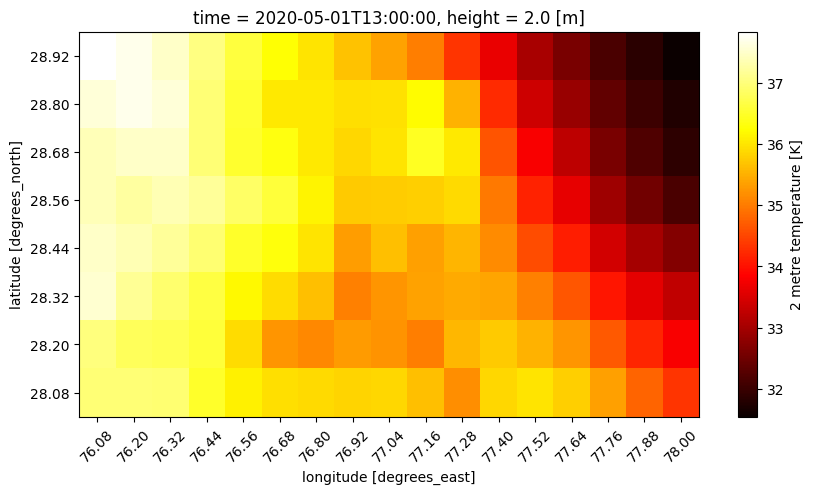

In [ ]:
import matplotlib.pyplot as plt

temperature = (ds["2t"] - 273.15).squeeze()

fig, ax = plt.subplots(figsize=(10,5))

temperature.plot(ax=ax, cmap="hot")

ax.set_xticks(ds.lon.values)
ax.set_yticks(ds.lat.values)

plt.xticks(rotation=45)

plt.show()

In [ ]:
temp_point = ds["2t"].sel(lat=28.32,lon=77.04,method="nearest")
print(temp_point)

<xarray.DataArray '2t' (time: 1, height: 1)> Size: 4B
array([[308.3885]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-05-01T13:00:00
  * height   (height) float64 8B 2.0
    lon      float64 8B 77.04
    lat      float64 8B 28.32
Attributes:
    standard_name:  air_temperature
    long_name:      2 metre temperature
    units:          K
    param:          0.0.0


In [ ]:
temp_c = ds["2t"] - 273.15
print("Maximum Temperature:", float(temp_c.max().values), "°C")

Maximum Temperature: 37.832244873046875 °C


In [ ]:
print("Minimum Temperature:", float(temp_c.min().values), "°C")

Minimum Temperature: 31.550994873046875 °C


In [ ]:
print("Average Temperature:", float(temp_c.mean().values), "°C")

Average Temperature: 35.404502868652344 °C
